This needs data available in ./parquet/*.parquet. If those files aren't available first run code in ./make_data.ipynb

In [21]:
import matplotlib.pyplot as plt
import numpy as np
import os
from pathlib import Path
import csv
import pyarrow.parquet as pq
import pandas as pd

In [3]:
!git clone https://github.com/DnlRKorn/histogram_for_sept26_hackathon

Cloning into 'histogram_for_sept26_hackathon'...
remote: Enumerating objects: 40, done.
remote: Counting objects: 100% (40/40), done.
remote: Compressing objects: 100% (24/24), done.
remote: Total 40 (delta 15), reused 40 (delta 15), pack-reused 0 (from 0)
Receiving objects: 100% (40/40), 39.71 MiB | 27.04 MiB/s, done.
Resolving deltas: 100% (15/15), done.


In [7]:
pq_path = "histogram_for_sept26_hackathon/data/parquet/diseases-diseases_confidence_score.parquet"

pq_file = pq.ParquetFile(pq_path)

In [8]:
prop_name = pq_file.schema[5].name

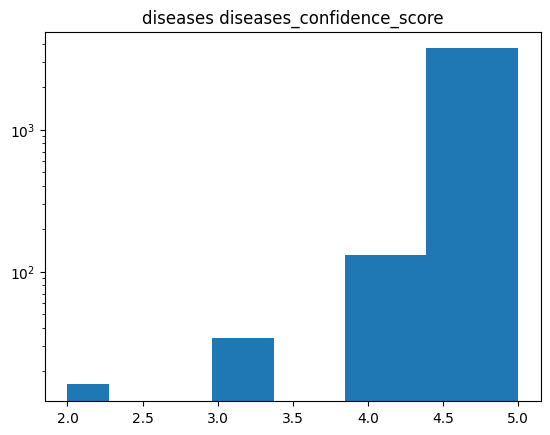

In [9]:
def plotHistogram(prop_vals:pd.Series, bins, log_y:bool=False, chart_title=""):
    fig, ax = plt.subplots()
    ax.set_title(chart_title)
    ax.hist(prop_vals, bins=bins,log=log_y)

def handleInputAndData(pq_path,bin_cnt:int,log_bins:bool,log_y:bool):
    chart_title = " ".join(Path(pq_path).stem.split('-'))

    pq_file = pq.ParquetFile(pq_path)
    prop_name = pq_file.schema[5].name
    arr = pq_file.read(columns=[prop_name])
    prop_vals = arr.to_pandas()[prop_name]
    if(log_bins):
        bins = np.logspace(np.log10(prop_vals.min()),np.log10(prop_vals.max()),bin_cnt)
    else: #No need to take the bins to log space, just let matplot handle the splitting
        bins = bin_cnt
    plotHistogram(prop_vals,bins,log_y,chart_title)
handleInputAndData(pq_path,8,True,True)

In [27]:
def getPresentAbsentCnts(dataset_name):
    ingest_name,prop = dataset_name.split("-")
    with open("histogram_for_sept26_hackathon/data/prop_seen_absent_cnt.csv") as f:
        dreader = csv.DictReader(f)
        for d in dreader:
            print(d)
            if((d["ingest_name"]==ingest_name) and (d["prop_name"]==prop)):
                return d
print(getPresentAbsentCnts('alliance','publications'))

{'ingest_name': 'pubtator', 'prop_name': 'publications', 'present_cnt': '10890003', 'absent_cnt': '0'}
{'ingest_name': 'semmeddb', 'prop_name': 'publications', 'present_cnt': '1724481', 'absent_cnt': '0'}
{'ingest_name': 'signor', 'prop_name': 'publications', 'present_cnt': '43631', 'absent_cnt': '0'}
{'ingest_name': 'tmkp', 'prop_name': 'publications', 'present_cnt': '1485506', 'absent_cnt': '0'}
{'ingest_name': 'goa', 'prop_name': 'has_evidence_of_type', 'present_cnt': '2135407', 'absent_cnt': '0'}
{'ingest_name': 'hpoa', 'prop_name': 'has_evidence_of_type', 'present_cnt': '262360', 'absent_cnt': '335637'}
{'ingest_name': 'gene2phenotype', 'prop_name': 'gene2phenotype_confidence_category', 'present_cnt': '3102', 'absent_cnt': '0'}
None


pubtator-publications


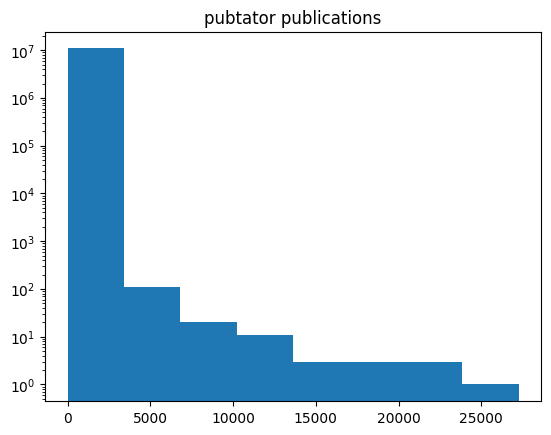

In [37]:
# @title Example form fields
# @markdown Forms support many types of fields.

num_bins = 20 # @param {type: "number"}
log_bin_size = False # @param {type:"boolean"}
log_bin_height = True # @param {type:"boolean"}
dataset = "pubtator-publications"  # @param ['alliance-publications', 'bindingdb-publications', 'chembl-has_confidence_score', 'chembl-publications', 'cohd-has_confidence_score', 'ctd-adjusted_p_value', 'ctd-p_value', 'ctd-publications', 'dakp-number_of_cases', 'dakp-publications', 'dgidb-dgidb_evidence_score', 'dgidb-dgidb_interaction_score', 'dgidb-publications', 'diseases-diseases_confidence_score', 'drugcentral-publications', 'gene2phenotype-gene2phenotype_confidence_category', 'gene2phenotype-publications', 'go_cam-publications', 'goa-has_evidence_of_type', 'goa-publications', 'gtopdb-publications', 'hpoa-has_evidence_of_type', 'hpoa-publications', 'intact-publications', 'pubtator-publications', 'semmeddb-publications', 'signor-has_confidence_score', 'signor-publications', 'tmkp-evidence_count', 'tmkp-publications']
# @markdown ---

print(dataset)
pq_path = os.path.join("histogram_for_sept26_hackathon","data","parquet",dataset+".parquet")
handleInputAndData(pq_path,8,log_bin_size,log_bin_height)
print(getPresentAbsentCnts(dataset))